# DBGSOM vs. MiniSom vs. SuSi vs. TorchSOM — Comparison

This notebook compares DBGSOM (`SomVQ`) with [justglowing/minisom](https://github.com/JustGlowing/minisom), [felixriese/susi](https://github.com/felixriese/susi), and [torchsom](https://github.com/MiguelMontesLorenzo/torchsom) on the scikit-learn Digits dataset.

## Algorithm Overview

| Property         | DBGSOM                                                              | MiniSom                         | SuSi                                         | TorchSOM                                      |
| ---------------- | ------------------------------------------------------------------- | ------------------------------- | -------------------------------------------- | --------------------------------------------- |
| Learning rule    | **Batch** (all samples per epoch)                                   | **Online** (sample-by-sample)   | Online or **Batch**                          | **Mini-batch** (configurable `batch_size`)     |
| Grid topology    | Rectangular (grows dynamically)                                     | Rectangular / hexagonal (fixed) | Rectangular (fixed)                          | Rectangular / hexagonal (fixed)               |
| Growth criterion | Neuron added where accumulated error exceeds growing threshold (GT) | —                               | —                                            | —                                             |
| Initialization   | 4 neurons (chosen from training samples)                            | Random or PCA                   | Random or PCA                                | Random or PCA                                 |
| API              | **sklearn-compatible** (`fit` / `transform` / `predict`)            | Custom API (`train` / `winner`) | **sklearn-compatible** (`fit` / `transform`) | PyTorch `nn.Module` (not sklearn-compatible)  |
| Neighborhood     | Gaussian decay over epochs                                          | Gaussian decay over iterations  | Pseudo-Gaussian or Mexican Hat               | Gaussian decay (configurable)                 |
| Distance metrics | Euclidean, Cosine                                                   | Euclidean                       | Euclidean, Manhattan, Mahalanobis, Tanimoto  | Euclidean, Cosine, Manhattan                  |
| GPU support      | No                                                                  | No                              | No                                           | **Yes** (`device` parameter)                  |

> **Same topology, different sizing:** All four SOMs use a rectangular grid. The key difference is that DBGSOM determines the grid size dynamically: a new neuron is inserted adjacent to all neurons whose error exceeds the growing threshold GT. MiniSom, SuSi, and TorchSOM require grid dimensions to be fixed before training.

**Fair comparison:** Because DBGSOM grows dynamically, we first train DBGSOM to determine its final neuron count `N`, then configure the other models with a `ceil(sqrt(N)) × floor(sqrt(N))` grid — giving all models an approximately equal neuron budget.

## Imports


In [1]:
import math
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from minisom import MiniSom
from sklearn.cluster import KMeans
from sklearn.datasets import load_digits
from sklearn.metrics.pairwise import euclidean_distances
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torchsom import SOM as TorchSOM

from dbgsom.SomVQ import SomVQ

## Dataset

We use the scikit-learn **Digits** dataset: 1 797 samples, 64 features (8×8 pixel images of handwritten digits 0–9).


In [2]:
X, y = load_digits(return_X_y=True)
X = StandardScaler().fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(
    f"Dataset: {X.shape[0]} samples, {X.shape[1]} features, {len(np.unique(y))} classes"
)
print(f"Train: {len(X_train)}  Test: {len(X_test)}")

Dataset: 1797 samples, 64 features, 10 classes
Train: 1437  Test: 360


## Step 1 — Train DBGSOM

DBGSOM starts with 4 neurons and grows until `max_neurons` is reached or convergence is detected.


In [3]:
som_db = SomVQ(
    n_iter=500,
    lambda_=53.5,
    max_neurons=100,
    decay_function="linear",
    sigma_end=1,
    verbose=True,
    random_state=42,
)

t0 = time.perf_counter()
som_db.fit(X_train)
t_db = time.perf_counter() - t0

n_neurons_db = len(som_db.neurons_)
print(f"DBGSOM: {n_neurons_db} neurons after {t_db:.2f}s")

 21%|██        | 103/500 [00:08<00:31, 12.60 epochs/s]

DBGSOM: 40 neurons after 8.19s


## Step 2 — Train MiniSom

MiniSom uses a fixed rectangular grid. We choose `side = ceil(sqrt(N))` so the total neuron count is close to DBGSOM's final count.

MiniSom's `train_batch` implements the same batch update principle as DBGSOM: weights updated after all samples as a neighbourhood-weighted average. For batch SOM the learning rate is theoretically 1.0 — the weighted average formula is already self-normalising, so `learning_rate < 1` only slows convergence without theoretical justification.

In [4]:
side = math.ceil(math.sqrt(n_neurons_db))
side2 = math.floor(math.sqrt(n_neurons_db))
n_neurons_ms = side * side2

som_ms = MiniSom(
    x=side,
    y=side2,
    input_len=X_train.shape[1],
    sigma=0.2 * np.sqrt(side**2),
    learning_rate=1.0,  # batch SOM: weighted average, lr=1 is theoretically correct
    random_seed=42,
)
som_ms.pca_weights_init(X_train)

t0 = time.perf_counter()
som_ms.train_batch(X_train, num_iteration=100 * len(X_train))
t_ms = time.perf_counter() - t0

print(f"MiniSom:  {n_neurons_ms} neurons ({side}×{side2} grid) after {t_ms:.2f}s")

MiniSom:  42 neurons (7×6 grid) after 6.88s


## Step 3 — Train SuSi

SuSi (`SOMClustering`) is an sklearn-compatible SOM library supporting online and batch training with multiple distance metrics. We use the same grid dimensions as MiniSom.

> **Note on topographic error:** SuSi does not provide a built-in topographic error. It is computed here using the same Kohonen definition as MiniSom: fraction of samples whose 1st and 2nd BMU are not adjacent in the grid.


In [5]:
from susi import SOMClustering

susi_rows, susi_cols = side, side2


def rectangular_topographic_error(weights_3d, X):
    n_rows, n_cols, _ = weights_3d.shape
    weights_flat = weights_3d.reshape(-1, X.shape[1])
    errors = 0
    for x in X:
        dists = np.linalg.norm(weights_flat - x, axis=1)
        idx1, idx2 = np.argsort(dists)[:2]
        r1, c1 = divmod(idx1, n_cols)
        r2, c2 = divmod(idx2, n_cols)
        if abs(r1 - r2) > 1 or abs(c1 - c2) > 1:
            errors += 1
    return errors / len(X)


t0 = time.perf_counter()
susi_som = SOMClustering(
    n_rows=susi_rows,
    n_columns=susi_cols,
    n_iter_unsupervised=1000,
    train_mode_unsupervised="online",
    random_state=42,
)
susi_som.fit(X_train)
t_susi = time.perf_counter() - t0

n_neurons_susi = susi_rows * susi_cols
print(
    f"SuSi:     {n_neurons_susi} neurons ({susi_rows}×{susi_cols} grid) after {t_susi:.2f}s"
)

SuSi:     42 neurons (7×6 grid) after 0.12s


## Step 4 — Train TorchSOM

TorchSOM is a PyTorch `nn.Module` implementation with GPU support and configurable batch size. We use full-batch mode (`batch_size=len(X_train)`) so the update rule is identical to MiniSom's `train_batch`, making the comparison fair. PCA initialization is used to match the other models.

> **Neighbourhood definition:** TorchSOM computes TE using Euclidean distance between BMU grid coordinates with threshold 1.0. Diagonal neighbours have distance √2 ≈ 1.41 > 1.0, so they are flagged as errors — this is the **4-neighbourhood** definition, identical to MiniSom's built-in `topographic_error()`. TorchSOM and MiniSom TE values are directly comparable; both are structurally higher than DBGSOM/SuSi (8-neighbourhood).

In [6]:
X_train_t = torch.tensor(X_train, dtype=torch.float32)
X_test_t = torch.tensor(X_test, dtype=torch.float32)

som_ts = TorchSOM(
    x=side,
    y=side2,
    num_features=X_train.shape[1],
    epochs=20,
    batch_size=len(X_train),  # full-batch: same principle as MiniSom train_batch
    sigma=0.2 * np.sqrt(side**2),
    learning_rate=1.0,  # full-batch: weighted average, lr=1 is theoretically correct
    topology="rectangular",
    initialization_mode="pca",
    random_seed=42,
)
som_ts.initialize_weights(X_train_t, mode="pca")

t0 = time.perf_counter()
som_ts.fit(X_train_t, verbose=False)
t_ts = time.perf_counter() - t0

n_neurons_ts = side * side2
print(f"TorchSOM: {n_neurons_ts} neurons ({side}×{side2} grid) after {t_ts:.2f}s")

TorchSOM: 42 neurons (7×6 grid) after 0.31s


## Step 5 — Train KMeans (Reference Lower Bound)

KMeans minimises quantization error by definition (Lloyd's algorithm), making it a lower bound on QE for any SOM with the same number of centroids. It has no topographic structure.

In [7]:
t0 = time.perf_counter()
km = KMeans(n_clusters=n_neurons_db, n_init=10, random_state=42)
km.fit(X_train)
t_km = time.perf_counter() - t0
print(f"KMeans:  {n_neurons_db} centroids after {t_km:.2f}s")

Exception in thread Thread-5 (_readerthread):
Traceback (most recent call last):
  File "C:\Users\Sandro\AppData\Roaming\uv\python\cpython-3.13-windows-x86_64-none\Lib\threading.py", line 1044, in _bootstrap_inner
    self.run()
    ~~~~~~~~^^
  File "C:\Users\Sandro\AppData\Roaming\uv\python\cpython-3.13-windows-x86_64-none\Lib\threading.py", line 995, in run
    self._target(*self._args, **self._kwargs)
    ~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Sandro\AppData\Roaming\uv\python\cpython-3.13-windows-x86_64-none\Lib\subprocess.py", line 1615, in _readerthread
    buffer.append(fh.read())
                  ~~~~~~~^^
  File "C:\Users\Sandro\AppData\Roaming\uv\python\cpython-3.13-windows-x86_64-none\Lib\encodings\cp1252.py", line 23, in decode
    return codecs.charmap_decode(input,self.errors,decoding_table)[0]
           ~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
UnicodeDecodeError: 'charmap' codec can't decode byte 0x81 in position 144: character maps t

KMeans:  40 centroids after 2.32s


## Step 6 — Metrics Comparison

> **Note on topographic error definitions:**
>
> All four libraries use the Kohonen definition (fraction of samples whose 1st and 2nd BMU are not adjacent), but "adjacent" differs:
>
> | Library | Neighbourhood | Definition |
> |---------|--------------|------------|
> | **DBGSOM** | **8-neighbourhood** | Chebyshev distance between BMU coordinates ≤ 1 — diagonals count as adjacent (Villmann 1997) |
> | **MiniSom** | **4-neighbourhood** | Built-in `topographic_error()` — only up/down/left/right count as adjacent |
> | **SuSi** | **8-neighbourhood** | Custom function here uses `abs(Δrow) > 1 or abs(Δcol) > 1` — diagonals count as adjacent |
> | **TorchSOM** | **4-neighbourhood** | Built-in `topographic_error()` — Euclidean threshold = 1.0; diagonal distance √2 > 1 → not adjacent |
>
> MiniSom and TorchSOM use the stricter 4-neighbourhood: a diagonal neighbour that DBGSOM or SuSi accept as adjacent is flagged as an error. **MiniSom and TorchSOM TE values are directly comparable to each other; DBGSOM and SuSi are directly comparable to each other. Cross-group comparison is misleading.**
>
> The Chebyshev (8-neighbourhood) definition follows Villmann et al. (1997): on a rectangular grid, diagonal Voronoi cells share a boundary point, so their BMUs are topologically adjacent in the weak neighbourhood topology induced by the maximum norm.

In [8]:
qe_db = som_db.calculate_quantization_error(X_test)
qe_ms = som_ms.quantization_error(X_test)
qe_susi = susi_som.get_quantization_error()
qe_ts = som_ts.quantization_error(X_test_t)
qe_km = np.mean(np.min(euclidean_distances(X_test, km.cluster_centers_), axis=1))

te_db = som_db.topographic_error_
te_ms = som_ms.topographic_error(X_test)
te_susi = rectangular_topographic_error(susi_som.unsuper_som_, X_test)
te_ts = som_ts.topographic_error(X_test_t)

metrics = pd.DataFrame(
    {
        "Metric": [
            "Training time (s)",
            "Neuron count",
            "Quantization error (test)",
            "Topographic error (train)",
            "TE neighbourhood",
        ],
        "DBGSOM": [
            f"{t_db:.2f}",
            n_neurons_db,
            f"{qe_db:.4f}",
            f"{te_db:.4f}",
            "8-nbr (Chebyshev)",
        ],
        "MiniSom": [
            f"{t_ms:.2f}",
            n_neurons_ms,
            f"{qe_ms:.4f}",
            f"{te_ms:.4f}",
            "4-nbr (Manhattan)",
        ],
        "SuSi": [
            f"{t_susi:.2f}",
            n_neurons_susi,
            f"{qe_susi:.4f}",
            f"{te_susi:.4f}",
            "8-nbr (Chebyshev)",
        ],
        "TorchSOM": [
            f"{t_ts:.2f}",
            n_neurons_ts,
            f"{qe_ts:.4f}",
            f"{te_ts:.4f}",
            "4-nbr (Euclidean)",
        ],
        "KMeans (ref)": [
            f"{t_km:.2f}",
            n_neurons_db,
            f"{qe_km:.4f}",
            "—",
            "N/A",
        ],
    }
).set_index("Metric")

metrics

,DBGSOM,MiniSom,SuSi,TorchSOM,KMeans (ref)
Metric,,,,,
Training time (s),8.19,6.88,0.12,0.31,2.32
Neuron count,40,42,42,42,40
Quantization error (test),5.5525,5.3820,5.8094,6.0251,4.9104
Topographic error (train),0.0376,0.3250,0.0139,0.0944,—
TE neighbourhood,8-nbr (Chebyshev),4-nbr (Manhattan),8-nbr (Chebyshev),4-nbr (Euclidean),N/A


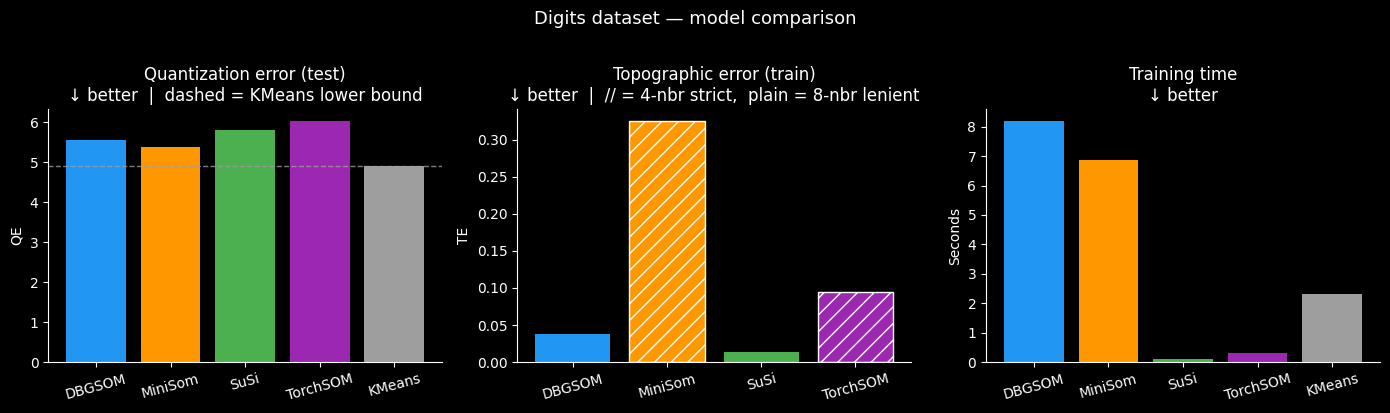

In [9]:
_methods = ["DBGSOM", "MiniSom", "SuSi", "TorchSOM"]
_colors = ["#2196F3", "#FF9800", "#4CAF50", "#9C27B0"]
_gray = "#9E9E9E"

_qe = [float(qe_db), float(qe_ms), float(qe_susi), float(qe_ts)]
_te = [float(te_db), float(te_ms), float(te_susi), float(te_ts)]
_time_vals = [t_db, t_ms, t_susi, t_ts]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# QE — KMeans is the lower bound
axes[0].bar(_methods + ["KMeans"], _qe + [float(qe_km)], color=_colors + [_gray])
axes[0].axhline(float(qe_km), color=_gray, linestyle="--", linewidth=1, alpha=0.8)
axes[0].set_title("Quantization error (test)\n↓ better  |  dashed = KMeans lower bound")
axes[0].set_ylabel("QE")

# TE — hatch marks 4-nbr (stricter) methods so groups are visually distinct
bars_te = axes[1].bar(_methods, _te, color=_colors)
for bar, method in zip(bars_te, _methods):
    if method in ("MiniSom", "TorchSOM"):  # 4-nbr strict
        bar.set_hatch("//")
        bar.set_edgecolor("white")
axes[1].set_title(
    "Topographic error (train)\n↓ better  |  // = 4-nbr strict,  plain = 8-nbr lenient"
)
axes[1].set_ylabel("TE")

# Training time
axes[2].bar(_methods + ["KMeans"], _time_vals + [t_km], color=_colors + [_gray])
axes[2].set_title("Training time\n↓ better")
axes[2].set_ylabel("Seconds")

for ax in axes:
    ax.tick_params(axis="x", rotation=15)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.suptitle("Digits dataset — model comparison", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## Step 7 — Visualization

All four SOMs are projected into the same 2D PCA space (PCA fitted on the data `X`), so neuron positions are directly comparable. Color encodes the mean distance to neighboring neurons (normalized to [0, 1]) — equivalent to a U-Matrix, darker = larger inter-neuron distances = cluster boundary.

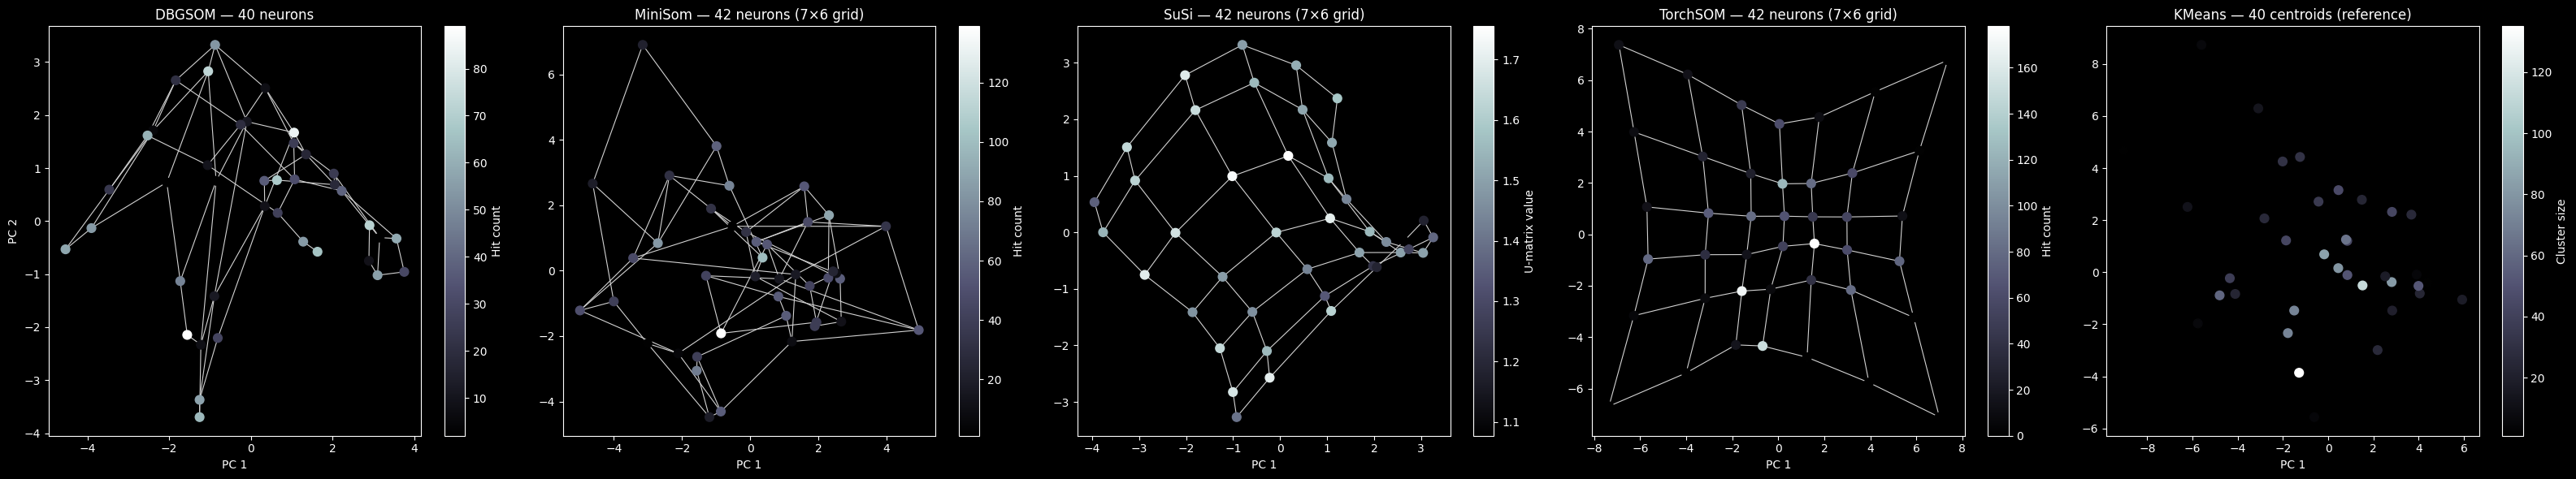

In [10]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
pca.fit(X)

fig, axes = plt.subplots(1, 5, figsize=(32, 6))

# --- DBGSOM ---
weights_db_2d = pca.transform(som_db.weights_)
avg_dist = np.array(
    [som_db.som_.nodes[n].get("hit_count", 0.0) for n in som_db.neurons_]
)

ax = axes[0]
ax.set_title(f"DBGSOM — {n_neurons_db} neurons", fontsize=12)

node_pos = dict(zip(som_db.neurons_, weights_db_2d))
for u, v in som_db.som_.edges():
    x0, y0 = node_pos[u]
    x1, y1 = node_pos[v]
    ax.plot([x0, x1], [y0, y1], color="lightgray", linewidth=0.8, zorder=1)

sc = ax.scatter(
    weights_db_2d[:, 0], weights_db_2d[:, 1], c=avg_dist, cmap="bone", s=60, zorder=2
)
plt.colorbar(sc, ax=ax, label="Hit count")
ax.set_xlabel("PC 1")
ax.set_ylabel("PC 2")

# --- MiniSom ---
ms_weights = som_ms.get_weights()
ms_weights_flat = ms_weights.reshape(-1, X.shape[1])
weights_ms_2d = pca.transform(ms_weights_flat)
umatrix = som_ms.activation_response(X)
umatrix_flat = umatrix.reshape(-1)

ax = axes[1]
ax.set_title(f"MiniSom — {n_neurons_ms} neurons ({side}×{side2} grid)", fontsize=12)

for i in range(side):
    for j in range(side2):
        idx = i * side2 + j
        if i + 1 < side:
            nb = (i + 1) * side2 + j
            ax.plot(
                [weights_ms_2d[idx, 0], weights_ms_2d[nb, 0]],
                [weights_ms_2d[idx, 1], weights_ms_2d[nb, 1]],
                color="lightgray",
                linewidth=0.8,
                zorder=1,
            )
        if j + 1 < side2:
            nb = i * side2 + (j + 1)
            ax.plot(
                [weights_ms_2d[idx, 0], weights_ms_2d[nb, 0]],
                [weights_ms_2d[idx, 1], weights_ms_2d[nb, 1]],
                color="lightgray",
                linewidth=0.8,
                zorder=1,
            )

sc = ax.scatter(
    weights_ms_2d[:, 0],
    weights_ms_2d[:, 1],
    c=umatrix_flat,
    cmap="bone",
    s=60,
    zorder=2,
)
plt.colorbar(sc, ax=ax, label="Hit count")
ax.set_xlabel("PC 1")

# --- SuSi ---
susi_weights_flat = susi_som.unsuper_som_.reshape(-1, X.shape[1])
weights_susi_2d = pca.transform(susi_weights_flat)
susi_umatrix = susi_som.get_u_matrix()[::2, ::2].reshape(-1)

ax = axes[2]
ax.set_title(
    f"SuSi — {n_neurons_susi} neurons ({susi_rows}×{susi_cols} grid)", fontsize=12
)

for i in range(susi_rows):
    for j in range(susi_cols):
        idx = i * susi_cols + j
        if i + 1 < susi_rows:
            nb = (i + 1) * susi_cols + j
            ax.plot(
                [weights_susi_2d[idx, 0], weights_susi_2d[nb, 0]],
                [weights_susi_2d[idx, 1], weights_susi_2d[nb, 1]],
                color="lightgray",
                linewidth=0.8,
                zorder=1,
            )
        if j + 1 < susi_cols:
            nb = i * susi_cols + (j + 1)
            ax.plot(
                [weights_susi_2d[idx, 0], weights_susi_2d[nb, 0]],
                [weights_susi_2d[idx, 1], weights_susi_2d[nb, 1]],
                color="lightgray",
                linewidth=0.8,
                zorder=1,
            )

sc = ax.scatter(
    weights_susi_2d[:, 0],
    weights_susi_2d[:, 1],
    c=susi_umatrix,
    cmap="bone",
    s=60,
    zorder=2,
)
plt.colorbar(sc, ax=ax, label="U-matrix value")
ax.set_xlabel("PC 1")

# --- TorchSOM ---
ts_weights = som_ts.weights.detach().cpu().numpy()  # shape: (side, side2, n_features)
ts_weights_flat = ts_weights.reshape(-1, X.shape[1])
weights_ts_2d = pca.transform(ts_weights_flat)

ax = axes[3]
ax.set_title(f"TorchSOM — {n_neurons_ts} neurons ({side}×{side2} grid)", fontsize=12)

for i in range(side):
    for j in range(side2):
        idx = i * side2 + j
        if i + 1 < side:
            nb = (i + 1) * side2 + j
            ax.plot(
                [weights_ts_2d[idx, 0], weights_ts_2d[nb, 0]],
                [weights_ts_2d[idx, 1], weights_ts_2d[nb, 1]],
                color="lightgray",
                linewidth=0.8,
                zorder=1,
            )
        if j + 1 < side2:
            nb = i * side2 + (j + 1)
            ax.plot(
                [weights_ts_2d[idx, 0], weights_ts_2d[nb, 0]],
                [weights_ts_2d[idx, 1], weights_ts_2d[nb, 1]],
                color="lightgray",
                linewidth=0.8,
                zorder=1,
            )

ts_hit_counts = np.zeros(side * side2)
ts_weights_t = som_ts.weights.detach().cpu()
for x in torch.tensor(X, dtype=torch.float32):
    dists = torch.norm(ts_weights_t.reshape(-1, X.shape[1]) - x, dim=1)
    ts_hit_counts[dists.argmin().item()] += 1

sc = axes[3].scatter(
    weights_ts_2d[:, 0],
    weights_ts_2d[:, 1],
    c=ts_hit_counts,
    cmap="bone",
    s=60,
    zorder=2,
)
plt.colorbar(sc, ax=axes[3], label="Hit count")
axes[3].set_xlabel("PC 1")

# --- KMeans ---
km_centroids_2d = pca.transform(km.cluster_centers_)
km_counts = np.bincount(km.labels_, minlength=n_neurons_db)

ax = axes[4]
ax.set_title(f"KMeans — {n_neurons_db} centroids (reference)", fontsize=12)
sc = ax.scatter(
    km_centroids_2d[:, 0], km_centroids_2d[:, 1], c=km_counts, cmap="bone", s=60
)
plt.colorbar(sc, ax=ax, label="Cluster size")
ax.set_xlabel("PC 1")

plt.tight_layout()
plt.show()

## Summary

| Aspect                    | DBGSOM                                     | MiniSom                                            | SuSi                                         | TorchSOM                                      | KMeans                    |
| ------------------------- | ------------------------------------------ | -------------------------------------------------- | -------------------------------------------- | --------------------------------------------- | ------------------------- |
| **Best for**              | Unknown optimal map size; automatic sizing | Quick experiments; well-understood grid size       | sklearn pipelines; multiple distance metrics | GPU workloads; PyTorch ecosystem integration  | QE lower bound reference  |
| **Hyperparameter burden** | `lambda_`, `max_neurons`                   | Grid dimensions `x`, `y`, `learning_rate`, `sigma` | Grid dimensions, `n_iter_unsupervised`       | Grid dimensions, `epochs`, `batch_size`, `sigma`, `learning_rate` | `n_clusters` |
| **sklearn pipelines**     | Yes (`fit` / `transform` / `predict`)      | No (custom API)                                    | Yes (`fit` / `transform`)                    | No (PyTorch `nn.Module`)                      | Yes                       |
| **GPU support**           | No                                         | No                                                 | No                                           | **Yes** (`device="cuda"`)                     | No                        |
| **Growing overhead**      | Yes (error tracking + insertion per epoch) | No                                                 | No                                           | No                                            | No                        |
| **Grid topology**         | Rectangular, size determined automatically | Rectangular / hexagonal, fixed upfront             | Rectangular, fixed upfront                   | Rectangular / hexagonal, fixed upfront        | None                      |
| **Topographic structure** | Yes                                        | Yes                                                | Yes                                          | Yes                                           | No                        |
| **Distance metrics**      | Euclidean, Cosine                          | Euclidean                                          | Euclidean, Manhattan, Mahalanobis, Tanimoto  | Euclidean, Cosine, Manhattan                  | Euclidean                 |
| **TE neighbourhood**      | **8-neighbourhood** (Chebyshev, Villmann)  | **4-neighbourhood** (stricter)                     | **8-neighbourhood** (more lenient)           | **4-neighbourhood** (Euclidean threshold=1)   | N/A                       |
| **Maintained (2025)**     | ✓                                          | ✓ (bug fixes only)                                 | ✓                                            | ✓ (active)                                    | ✓ (sklearn)               |

DBGSOM trades off a slightly higher training cost for the ability to adapt the map size automatically, which is beneficial when the ideal number of neurons is not known in advance. SuSi offers the broadest choice of distance metrics and full sklearn compatibility with a fixed grid. TorchSOM is the only option with GPU support, making it the best choice when training on large datasets where PyTorch acceleration matters.

**KMeans as reference:** KMeans (with the same centroid count) represents the minimum achievable QE for a given number of prototypes — any SOM will have equal or higher QE due to the topographic neighbourhood constraint. The gap between SOM QE and KMeans QE quantifies the cost of preserving topology.

> **Topographic error caveat:** DBGSOM and SuSi use an 8-neighbourhood (Chebyshev distance ≤ 1, diagonals included). MiniSom and TorchSOM use a stricter 4-neighbourhood (diagonals have Euclidean distance √2 > 1.0 → counted as errors). TE values are only directly comparable within each group.

---

## Scaling Test — Fashion-MNIST

To stress-test scaling behaviour we use a 10 000-sample subset of Fashion-MNIST (784 features, 10 classes) — roughly 5.6× more samples and 12× more features than Digits.

Training budgets are scaled proportionally:

- **DBGSOM**: same epoch count (`n_iter=300`), `max_neurons=100`
- **MiniSom**: `num_iteration = 50 × N` (reduced from 300× to keep runtime tractable)
- **SuSi**: `n_iter_unsupervised = 50 000` (~5× passes over all samples)
- **TorchSOM**: `epochs=100`, `batch_size=len(X_train_l)` (full-batch)

> **SuSi note:** In online mode each iteration draws _one_ random sample, independent of N. To expose the SOM to all data ~5 times we set `n_iter = 5 × N`. This is the key scaling difference from DBGSOM and MiniSom.
>
> **TorchSOM note:** On CPU each full-batch epoch computes all pairwise distances as a vectorised tensor op — it benefits most from GPU (`device="cuda"`) on larger maps.

In [11]:
from sklearn.datasets import fetch_openml

n_samples = 70_000
fmnist = fetch_openml("Fashion-MNIST", version=1, as_frame=False, parser="auto")
X_all = StandardScaler().fit_transform(fmnist.data[:n_samples].astype(float))
y_all = fmnist.target[:n_samples]

X_train_l, X_test_l, y_train_l, y_test_l = train_test_split(
    X_all, y_all, test_size=0.2, random_state=42, stratify=y_all
)
print(
    f"Dataset: {X_all.shape[0]} samples, {X_all.shape[1]} features, {len(np.unique(y_all))} classes"
)
print(f"Train: {len(X_train_l)}  Test: {len(X_test_l)}")

Dataset: 70000 samples, 784 features, 10 classes
Train: 56000  Test: 14000


In [49]:
som_db_l = SomVQ(
    n_iter=2000,
    lambda_=100,
    max_neurons=1000,
    pointer_search="all",
    smoothing_steps=1,
    verbose=True,
    # sigma_end=1,
    neighborhood_function="cutgauss",
    neighborhood_cutoff=3,
    random_state=42,
)
t0 = time.perf_counter()
som_db_l.fit(X_train_l)
t_db_l = time.perf_counter() - t0
n_neurons_db_l = len(som_db_l.neurons_)
print(f"DBGSOM:   {n_neurons_db_l} neurons after {t_db_l:.2f}s")

side_l = math.ceil(math.sqrt(n_neurons_db_l))
side2_l = math.floor(math.sqrt(n_neurons_db_l))
n_neurons_ms_l = side_l * side2_l

som_ms_l = MiniSom(
    x=side_l,
    y=side2_l,
    input_len=X_train_l.shape[1],
    sigma=0.2 * np.sqrt(side_l**2),
    learning_rate=1.0,
    random_seed=42,
)
som_ms_l.pca_weights_init(X_train_l)
t0 = time.perf_counter()
som_ms_l.train_batch(X_train_l, num_iteration=1 * len(X_train_l))
t_ms_l = time.perf_counter() - t0
print(f"MiniSom:  {n_neurons_ms_l} neurons ({side_l}×{side2_l}) after {t_ms_l:.2f}s")

susi_rows_l, susi_cols_l = side_l, side2_l
susi_som_l = SOMClustering(
    n_rows=susi_rows_l,
    n_columns=susi_cols_l,
    n_iter_unsupervised=1 * len(X_train_l),
    train_mode_unsupervised="online",
    random_state=42,
)
t0 = time.perf_counter()
susi_som_l.fit(X_train_l)
t_susi_l = time.perf_counter() - t0
n_neurons_susi_l = susi_rows_l * susi_cols_l
print(
    f"SuSi:     {n_neurons_susi_l} neurons ({susi_rows_l}×{susi_cols_l}) after {t_susi_l:.2f}s"
)

X_train_lt = torch.tensor(X_train_l, dtype=torch.float32)
X_test_lt = torch.tensor(X_test_l, dtype=torch.float32)

som_ts_l = TorchSOM(
    x=side_l,
    y=side2_l,
    num_features=X_train_l.shape[1],
    epochs=20,
    batch_size=len(X_train_l),  # full-batch
    sigma=0.2 * np.sqrt(side_l**2),
    learning_rate=1.0,
    topology="rectangular",
    initialization_mode="pca",
    random_seed=42,
    device="cuda",
)
som_ts_l.initialize_weights(X_train_lt, mode="pca")
t0 = time.perf_counter()
som_ts_l.fit(X_train_lt, verbose=False)
t_ts_l = time.perf_counter() - t0
n_neurons_ts_l = side_l * side2_l
print(f"TorchSOM: {n_neurons_ts_l} neurons ({side_l}×{side2_l}) after {t_ts_l:.2f}s")

 25%|██▍       | 494/2000 [00:24<01:15, 19.99 epochs/s]


DBGSOM:   247 neurons after 27.02s
MiniSom:  240 neurons (16×15) after 80.37s
SuSi:     240 neurons (16×15) after 187.32s
TorchSOM: 240 neurons (16×15) after 9.77s


In [50]:
t0 = time.perf_counter()
km_l = KMeans(n_clusters=n_neurons_db_l, random_state=42)
km_l.fit(X_train_l)
t_km_l = time.perf_counter() - t0
print(f"KMeans:  {n_neurons_db_l} centroids after {t_km_l:.2f}s")

KMeans:  247 centroids after 23.70s


In [51]:
qe_db_l = som_db_l.calculate_quantization_error(X_test_l)
qe_ms_l = som_ms_l.quantization_error(X_test_l)
qe_susi_l = susi_som_l.get_quantization_error()
qe_ts_l = som_ts_l.quantization_error(X_test_lt)
qe_km_l = np.mean(np.min(euclidean_distances(X_test_l, km_l.cluster_centers_), axis=1))

te_db_l = som_db_l.topographic_error_
te_ms_l = som_ms_l.topographic_error(X_test_l)
te_susi_l = rectangular_topographic_error(susi_som_l.unsuper_som_, X_test_l)
te_ts_l = som_ts_l.topographic_error(X_test_lt)

pd.DataFrame(
    {
        "Metric": [
            "Training time (s)",
            "Neuron count",
            "Quantization error (test)",
            "Topographic error (test)",
            "TE neighbourhood",
        ],
        "DBGSOM": [
            f"{t_db_l:.2f}",
            n_neurons_db_l,
            f"{qe_db_l:.4f}",
            f"{te_db_l:.4f}",
            "8-nbr",
        ],
        "MiniSom": [
            f"{t_ms_l:.2f}",
            n_neurons_ms_l,
            f"{qe_ms_l:.4f}",
            f"{te_ms_l:.4f}",
            "4-nbr",
        ],
        "SuSi": [
            f"{t_susi_l:.2f}",
            n_neurons_susi_l,
            f"{qe_susi_l:.4f}",
            f"{te_susi_l:.4f}",
            "8-nbr",
        ],
        "TorchSOM": [
            f"{t_ts_l:.2f}",
            n_neurons_ts_l,
            f"{qe_ts_l:.4f}",
            f"{te_ts_l:.4f}",
            "4-nbr",
        ],
        "KMeans (ref)": [
            f"{t_km_l:.2f}",
            n_neurons_db_l,
            f"{qe_km_l:.4f}",
            "—",
            "N/A",
        ],
    }
).set_index("Metric")

,DBGSOM,MiniSom,SuSi,TorchSOM,KMeans (ref)
Metric,,,,,
Training time (s),27.02,80.37,187.32,9.77,23.70
Neuron count,247,240,240,240,247
Quantization error (test),15.5336,17.0581,16.5218,19.1780,14.8183
Topographic error (test),0.0914,0.0673,0.0257,0.0663,—
TE neighbourhood,8-nbr,4-nbr,8-nbr,4-nbr,N/A


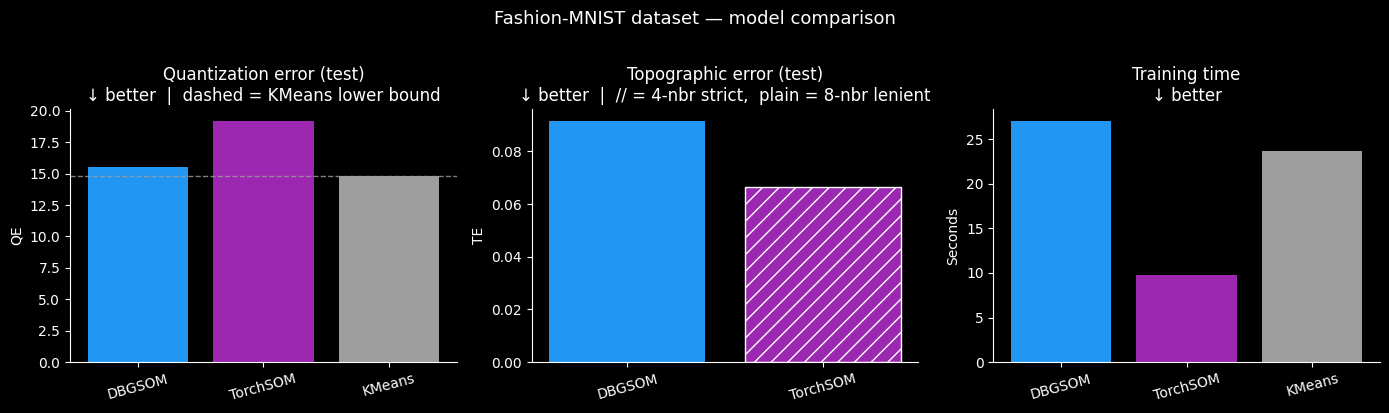

In [52]:
_gray = "#9E9E9E"

_methods_l = ["DBGSOM"]
_qe_l = [float(som_db_l.calculate_quantization_error(X_test_l))]
_te_l = [float(som_db_l.topographic_error_)]
_time_l = [t_db_l]
_colors_l = ["#2196F3"]
_hatch_l = [False]

try:
    _qe_ts_l = float(som_ts_l.quantization_error(X_test_lt))
    _te_ts_l = float(som_ts_l.topographic_error(X_test_lt))
    _methods_l.append("TorchSOM")
    _qe_l.append(_qe_ts_l)
    _te_l.append(_te_ts_l)
    _time_l.append(t_ts_l)
    _colors_l.append("#9C27B0")
    _hatch_l.append(True)
except NameError:
    pass  # TorchSOM training requires CUDA tensors — uncomment X_train_lt / X_test_lt in training cell

_qe_km_val = float(
    np.mean(np.min(euclidean_distances(X_test_l, km_l.cluster_centers_), axis=1))
)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].bar(_methods_l + ["KMeans"], _qe_l + [_qe_km_val], color=_colors_l + [_gray])
axes[0].axhline(_qe_km_val, color=_gray, linestyle="--", linewidth=1, alpha=0.8)
axes[0].set_title("Quantization error (test)\n↓ better  |  dashed = KMeans lower bound")
axes[0].set_ylabel("QE")

bars_te_l = axes[1].bar(_methods_l, _te_l, color=_colors_l)
for bar, hatch in zip(bars_te_l, _hatch_l):
    if hatch:
        bar.set_hatch("//")
        bar.set_edgecolor("white")
axes[1].set_title(
    "Topographic error (test)\n↓ better  |  // = 4-nbr strict,  plain = 8-nbr lenient"
)
axes[1].set_ylabel("TE")

axes[2].bar(_methods_l + ["KMeans"], _time_l + [t_km_l], color=_colors_l + [_gray])
axes[2].set_title("Training time\n↓ better")
axes[2].set_ylabel("Seconds")

for ax in axes:
    ax.tick_params(axis="x", rotation=15)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.suptitle("Fashion-MNIST dataset — model comparison", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

Steps= 2
6.00
169
16.7757
0.0404

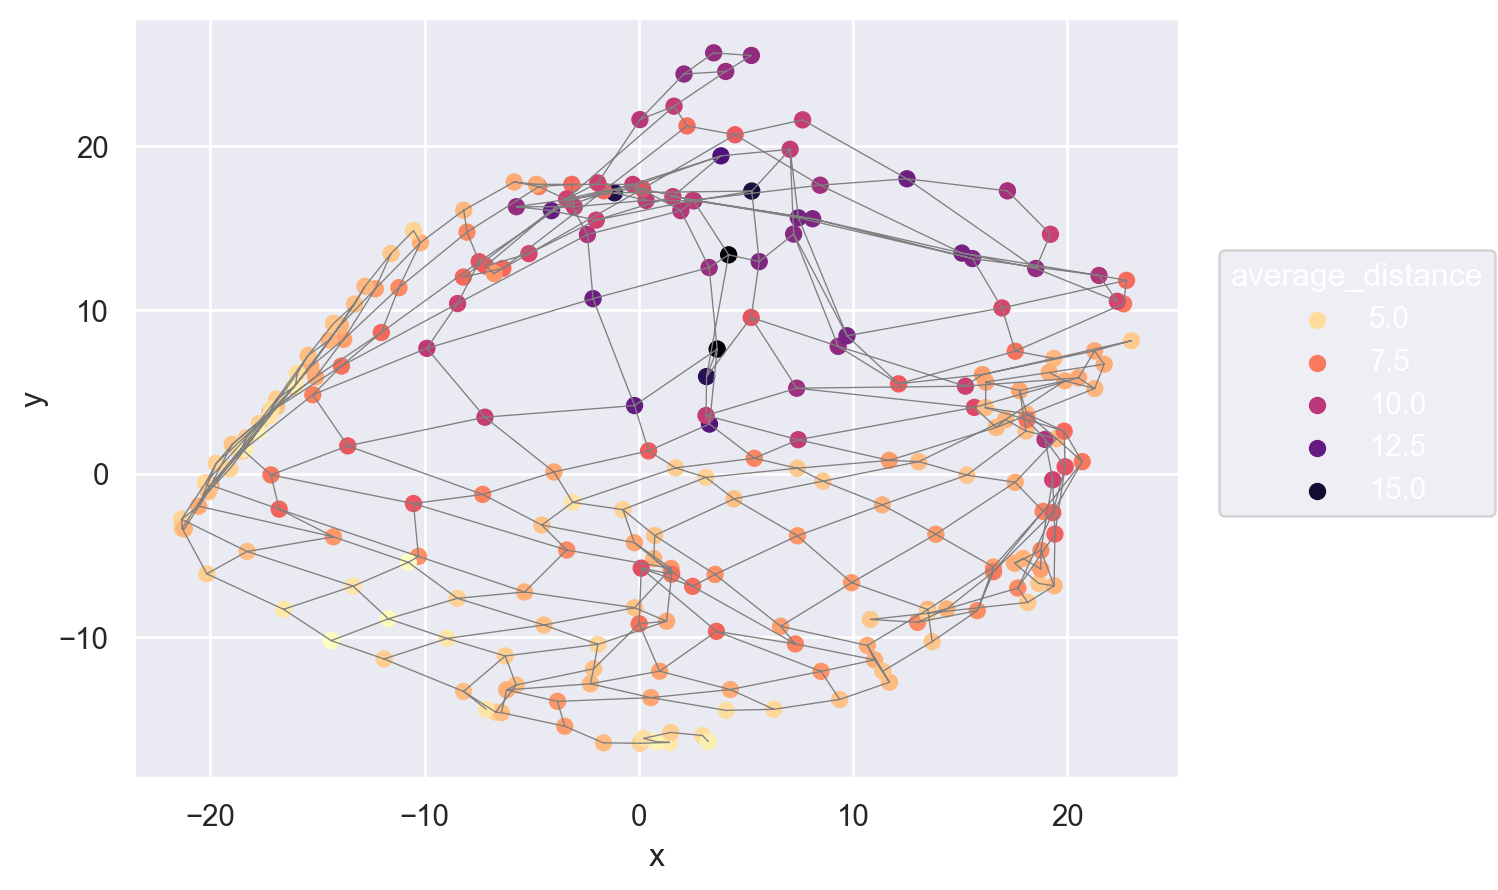

In [53]:
som_db_l.plot(color="average_distance", layout="pca", X=X_test_l)

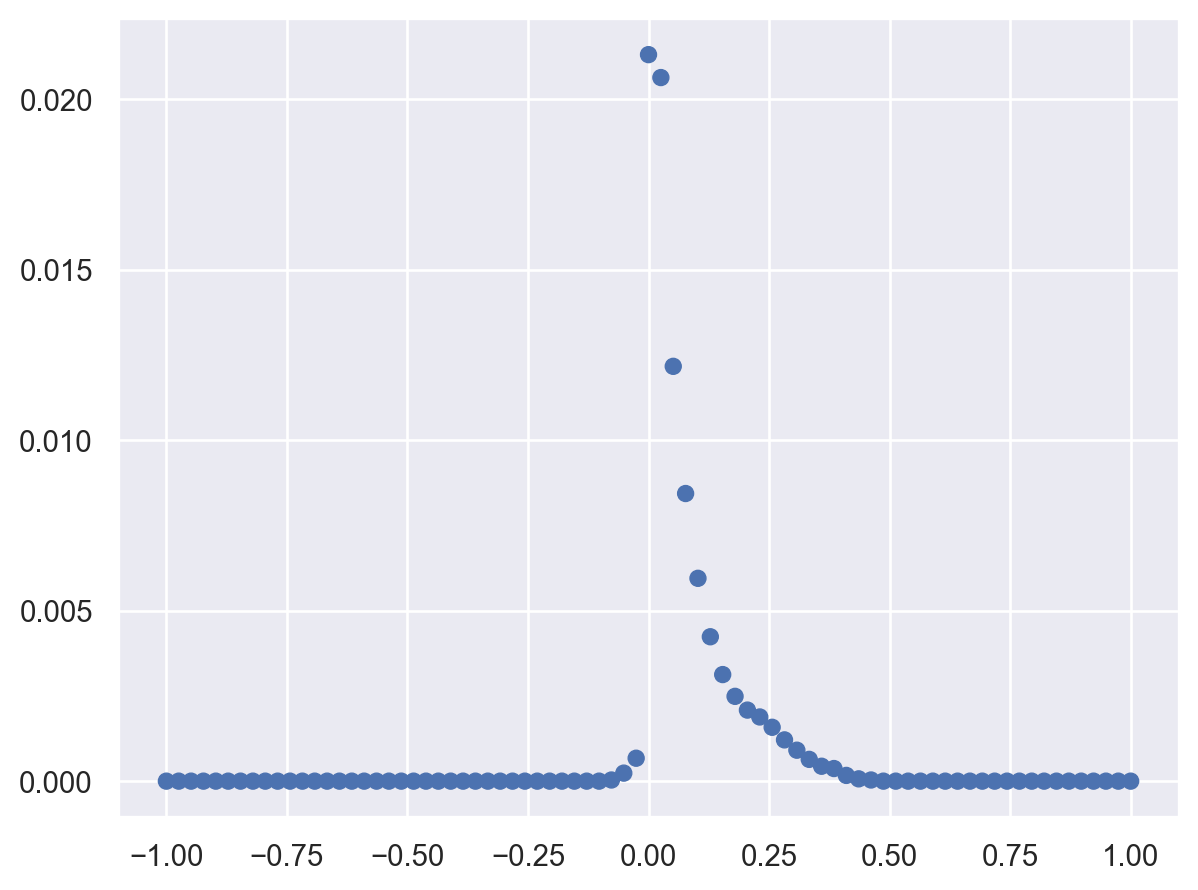

In [54]:
import seaborn.objects as so

so.Plot(
    x=som_db_l.topographic_function(X_test_l)[1],
    y=som_db_l.topographic_function(X_test_l)[0],
).add(so.Dot())